# Lecture 8 — Class Exercise
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json


## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from


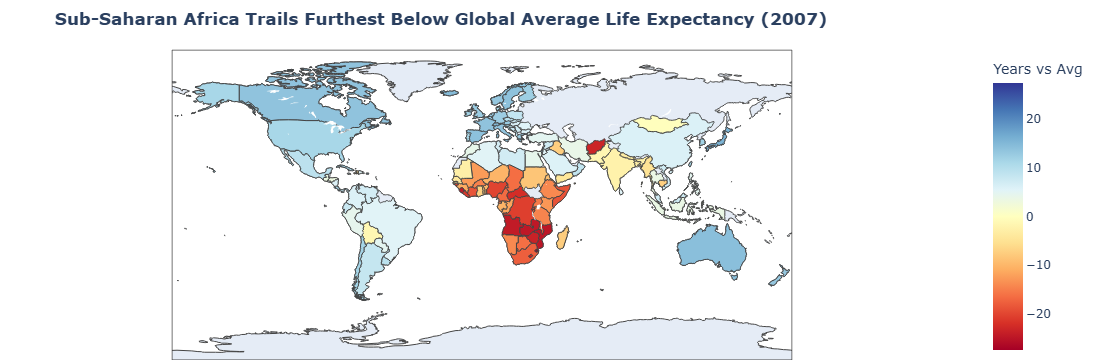

In [2]:
# Task 1
# YOUR CODE HERE
# Task 1
# Fetch the gapminder dataset and filter for 2007
gapminder = px.data.gapminder()
gm_2007 = gapminder[gapminder['year'] == 2007].copy()

# Compute the global mean life expectancy
global_mean = gm_2007['lifeExp'].mean()

# Compute each country's deviation from the global mean
gm_2007['lifeExp_deviation'] = gm_2007['lifeExp'] - global_mean

# Build the Choropleth map
fig1 = px.choropleth(
    gm_2007,
    locations="iso_alpha",          # Rule-compliant ISO-3 codes
    locationmode="ISO-3",           # Avoids the DeprecationWarning
    color="lifeExp_deviation",      # Diverging variable
    hover_name="country",
    hover_data={
        "iso_alpha": False,
        "lifeExp": ":.1f",          # Raw life expectancy formatted to 1 decimal
        "lifeExp_deviation": ":+.1f" # Explicitly shows + or - signs for deviation
    },
    color_continuous_scale=px.colors.diverging.RdYlBu,
    color_continuous_midpoint=0,    # Centers the color bar at the world average
    labels={
        "lifeExp_deviation": "Dev. from Avg (Years)",
        "lifeExp": "Life Expectancy"
    },
    title="<b>Sub-Saharan Africa Trails Furthest Below Global Average Life Expectancy (2007)</b>" # Geographic insight title
)

# Clean up layout appearance
fig1.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Years vs Avg") 
)

fig1.show()


## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`


**GeoJSON source:** *(URL or description)*

**Chart type chosen** (`px.choropleth` or `px.choropleth_mapbox`) **and reason:**

*Your answer here*
    px.choropleth

Reason:
I chose px.choropleth because this task uses polygon region boundaries (countries/states) and does not require a Mapbox token or street basemap. A standard choropleth is simpler, cleaner, and faster for thematic regional comparisons.

**Colour scale chosen** (sequential or diverging) **and reason:**

*Your answer here*
    Sequential scale (Viridis)

Reason:
The variable being mapped is GDP per capita, which ranges from low → high values with no meaningful midpoint such as zero. Sequential scales are best for showing increasing intensity.

{'name': 'Afghanistan'}


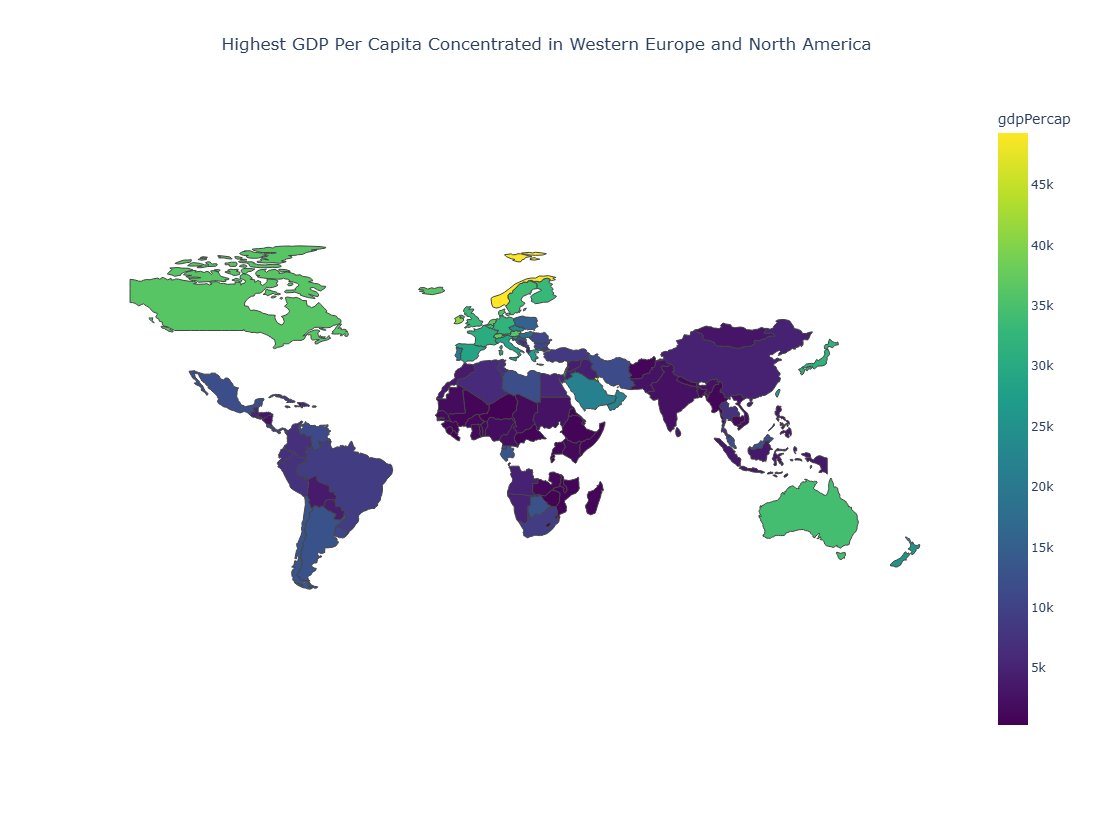

In [3]:
import pandas as pd
import plotly.express as px
import requests

# ---------------------------------------
# Load GeoJSON (countries)
# ---------------------------------------

geojson_url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"

geojson = requests.get(geojson_url).json()

# Inspect GeoJSON properties
print(geojson['features'][0]['properties'])

# ---------------------------------------
# Load dataset
# ---------------------------------------

gm = px.data.gapminder()
gm_2007 = gm[gm['year'] == 2007]

# Use GDP per capita by country
df = gm_2007[['country', 'gdpPercap']]

# ---------------------------------------
# Build choropleth
# ---------------------------------------

fig = px.choropleth(
    df,
    geojson=geojson,
    locations='country',
    featureidkey='properties.name',
    color='gdpPercap',
    color_continuous_scale='Viridis',
    hover_name='country',
    hover_data={'gdpPercap': ':.0f'},
    title='Highest GDP Per Capita Concentrated in Western Europe and North America',
    width=1400,
    height=800
)

# Fit map to locations
fig.update_geos(
    fitbounds="locations",
    visible=False
)

# Layout improvements
fig.update_layout(
    template='plotly_white',
    title_x=0.5
)

fig.show()